# Vision Transformer (ViT) for Image Classification

Implementation based on "An Image is Worth 16x16 Words" (Dosovitskiy et al., 2020).

**Architecture (following the lecture slides):**
1. **Patch Embedding:** Convert image to sequence of patch embeddings.
2. **Class Token + Position Encoding:** Add learnable [CLS] token and positional embeddings.
3. **Transformer Encoder:** L blocks with Layer Norm, Multi-Head Self-Attention, and MLP.
4. **Classification Head:** MLP on the [CLS] token output.

**Dependencies:** `torch`, `torchvision`, `numpy`, `matplotlib`, `scikit-learn`, `tqdm`, `Pillow`

## 1. Setup

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import math
from glob import glob
import os
from tqdm import tqdm
from sklearn.metrics import cohen_kappa_score, accuracy_score, confusion_matrix

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

Using device: cuda


## 2. Model Components

Each component corresponds to a block in the lecture slides. We build them bottom-up: Patch Embedding, Layer Normalization, Multi-Head Self-Attention, MLP, Transformer Block, and the complete ViT.

### 2.1 Patch Embedding

Divides the image into fixed-size patches and projects each to an embedding vector.

For image $\mathbf{x} \in \mathbb{R}^{H \times W \times C}$ with patch size $P$:
- Number of patches: $n = HW/P^2$
- Flattened patch $i$: $\mathbf{x}_p^i \in \mathbb{R}^{P^2 \cdot C}$
- Embedded patch: $\mathbf{z}_p^i = \mathbf{x}_p^i \mathbf{E}$, where $\mathbf{E} \in \mathbb{R}^{(P^2 C) \times d}$ is learnable.

Implemented efficiently as a convolution with `kernel_size=P` and `stride=P`.

In [2]:
class PatchEmbedding(nn.Module):
    def __init__(self, img_size=224, patch_size=16, in_channels=3, embed_dim=768):
        super().__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.n_patches = (img_size // patch_size) ** 2
        
        # Equivalent to flattening patches and applying a linear projection
        self.projection = nn.Conv2d(
            in_channels, embed_dim,
            kernel_size=patch_size, stride=patch_size
        )
        
    def forward(self, x):
        # x: (B, C, H, W) -> (B, n_patches, embed_dim)
        x = self.projection(x)       # (B, embed_dim, H/P, W/P)
        x = x.flatten(2)             # (B, embed_dim, n_patches)
        x = x.transpose(1, 2)        # (B, n_patches, embed_dim)
        return x

# Quick test
patch_embed = PatchEmbedding(img_size=224, patch_size=16, embed_dim=768)
dummy = torch.randn(1, 3, 224, 224)
out = patch_embed(dummy)
print(f"Input:  {dummy.shape}")
print(f"Output: {out.shape}  (1 image, {out.shape[1]} patches, {out.shape[2]}-dim embeddings)")

Input:  torch.Size([1, 3, 224, 224])
Output: torch.Size([1, 196, 768])  (1 image, 196 patches, 768-dim embeddings)


### 2.2 Layer Normalization

Normalizes each token independently across the embedding dimension.

$$\text{LN}(\mathbf{x})_i = \gamma_i \cdot \frac{x_i - \mu}{\sqrt{\sigma^2 + \epsilon}} + \beta_i$$

where $\gamma, \beta$ are learnable scale and shift parameters.

In [3]:
class LayerNorm(nn.Module):
    def __init__(self, dim, eps=1e-6):
        super().__init__()
        self.gamma = nn.Parameter(torch.ones(dim))
        self.beta = nn.Parameter(torch.zeros(dim))
        self.eps = eps
        
    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        x_norm = (x - mean) / torch.sqrt(var + self.eps)
        return self.gamma * x_norm + self.beta

### 2.3 Multi-Head Self-Attention

$$\text{Attention}(\mathbf{Q}, \mathbf{K}, \mathbf{V}) = \text{softmax}\left(\frac{\mathbf{Q}\mathbf{K}^T}{\sqrt{d_k}}\right)\mathbf{V}$$

Multiple heads capture different types of relationships. Outputs are concatenated and projected:
$$\text{MSA}(\mathbf{Z}) = \text{Concat}(\text{head}_1, \ldots, \text{head}_h)\mathbf{W}^O$$

In [4]:
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, embed_dim, num_heads, dropout=0.0):
        super().__init__()
        assert embed_dim % num_heads == 0
        
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        self.scale = self.head_dim ** -0.5
        
        self.qkv = nn.Linear(embed_dim, embed_dim * 3, bias=True)
        self.proj = nn.Linear(embed_dim, embed_dim)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x):
        B, N, D = x.shape
        
        # Q, K, V projections for all heads at once
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)    # (3, B, heads, N, head_dim)
        q, k, v = qkv[0], qkv[1], qkv[2]
        
        # Scaled dot-product attention
        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = F.softmax(attn, dim=-1)
        attn = self.dropout(attn)
        
        # Weighted sum of values
        x = (attn @ v).transpose(1, 2).reshape(B, N, D)
        
        # Output projection
        x = self.proj(x)
        x = self.dropout(x)
        return x

### 2.4 Feed-Forward Network (MLP)

Two-layer MLP with GELU activation, applied to each token independently:
$$\text{FFN}(\mathbf{z}) = \mathbf{W}_2 \cdot \text{GELU}(\mathbf{W}_1 \mathbf{z} + \mathbf{b}_1) + \mathbf{b}_2$$

Typically expands by factor 4 ($d_{ff} = 4d$), then compresses back.

In [5]:
class MLP(nn.Module):
    def __init__(self, embed_dim, mlp_ratio=4.0, dropout=0.0):
        super().__init__()
        hidden_dim = int(embed_dim * mlp_ratio)
        self.fc1 = nn.Linear(embed_dim, hidden_dim)
        self.act = nn.GELU()
        self.fc2 = nn.Linear(hidden_dim, embed_dim)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x):
        x = self.dropout(self.act(self.fc1(x)))
        x = self.dropout(self.fc2(x))
        return x

### 2.5 Transformer Encoder Block

Pre-LN architecture (modern standard):
1. Layer Norm + Multi-Head Self-Attention + Residual
2. Layer Norm + MLP + Residual

In [6]:
class TransformerEncoderBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, mlp_ratio=4.0, dropout=0.0):
        super().__init__()
        self.ln1 = LayerNorm(embed_dim)
        self.attn = MultiHeadSelfAttention(embed_dim, num_heads, dropout)
        self.ln2 = LayerNorm(embed_dim)
        self.mlp = MLP(embed_dim, mlp_ratio, dropout)
        
    def forward(self, x):
        x = x + self.attn(self.ln1(x))   # Attention + residual
        x = x + self.mlp(self.ln2(x))    # MLP + residual
        return x

## 3. Complete Vision Transformer

Assembles all components:

$$\mathbf{z}_0 = [\mathbf{x}_{class};\, \mathbf{x}_p^1\mathbf{E};\, \ldots;\, \mathbf{x}_p^n\mathbf{E}] + \mathbf{E}_{pos}$$

After $L$ encoder blocks, extract the [CLS] token for classification: $y = \text{MLP}(\mathbf{z}_L^0)$

In [7]:
class VisionTransformer(nn.Module):
    def __init__(self, img_size=224, patch_size=16, in_channels=3,
                 num_classes=1000, embed_dim=768, depth=12,
                 num_heads=12, mlp_ratio=4.0, dropout=0.1):
        super().__init__()
        self.embed_dim = embed_dim
        
        # Patch embedding
        self.patch_embed = PatchEmbedding(img_size, patch_size, in_channels, embed_dim)
        n_patches = self.patch_embed.n_patches
        
        # Learnable [CLS] token and positional embeddings
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, n_patches + 1, embed_dim))
        self.pos_drop = nn.Dropout(dropout)
        
        # Transformer encoder blocks
        self.blocks = nn.ModuleList([
            TransformerEncoderBlock(embed_dim, num_heads, mlp_ratio, dropout)
            for _ in range(depth)
        ])
        
        # Final layer norm + classification head
        self.norm = LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)
        
        # Initialize weights
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        self.apply(self._init_weights)
        
    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.trunc_normal_(m.weight, std=0.02)
            if m.bias is not None:
                nn.init.zeros_(m.bias)
    
    def forward(self, x):
        B = x.shape[0]
        
        # 1. Patch embedding
        x = self.patch_embed(x)
        
        # 2. Prepend [CLS] token
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls_tokens, x], dim=1)
        
        # 3. Add positional embeddings
        x = self.pos_drop(x + self.pos_embed)
        
        # 4. Transformer encoder
        for block in self.blocks:
            x = block(x)
        
        # 5. Extract [CLS] token and classify
        x = self.norm(x)
        cls_output = x[:, 0]
        logits = self.head(cls_output)
        return logits

In [8]:
# Create a small ViT and inspect it
# Using reduced dimensions for the Corel dataset (small dataset)
model = VisionTransformer(
    img_size=224, patch_size=16, in_channels=3,
    num_classes=6, embed_dim=256, depth=6,
    num_heads=8, mlp_ratio=4.0, dropout=0.1
).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")
print()
print(model)

Total parameters: 4,988,166

VisionTransformer(
  (patch_embed): PatchEmbedding(
    (projection): Conv2d(3, 256, kernel_size=(16, 16), stride=(16, 16))
  )
  (pos_drop): Dropout(p=0.1, inplace=False)
  (blocks): ModuleList(
    (0-5): 6 x TransformerEncoderBlock(
      (ln1): LayerNorm()
      (attn): MultiHeadSelfAttention(
        (qkv): Linear(in_features=256, out_features=768, bias=True)
        (proj): Linear(in_features=256, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ln2): LayerNorm()
      (mlp): MLP(
        (fc1): Linear(in_features=256, out_features=1024, bias=True)
        (act): GELU(approximate='none')
        (fc2): Linear(in_features=1024, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (norm): LayerNorm()
  (head): Linear(in_features=256, out_features=6, bias=True)
)


## 4. Dataset and Data Loaders

We use the Corel dataset (same as previous CNN notebooks). Images are in `./images/corel/` with filenames `<class>_<n>.png`.

In [9]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

class ImageDataset(Dataset):
    def __init__(self, file_list, transform=None):
        self.file_list = file_list
        self.transform = transform
        self.targets = [int(os.path.basename(x).split("_")[0]) - 1 for x in file_list]
        
    def __len__(self):
        return len(self.file_list)
    
    def __getitem__(self, idx):
        image = Image.open(self.file_list[idx]).convert('RGB')
        label = self.targets[idx]
        if self.transform:
            image = self.transform(image)
        return image, label

In [10]:
# Data transforms
img_size = 224

train_transform = transforms.Compose([
    transforms.Resize((300, 300), interpolation=transforms.InterpolationMode.BILINEAR),
    transforms.RandomAffine(degrees=10, translate=(0.05, 0.10), scale=(0.9, 1.1), shear=(-2, 2)),
    transforms.CenterCrop(250),
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

val_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

# Load and split data
orig_dir = '../images/corel'
nclasses = 6

data_files = glob(os.path.join(orig_dir, '*.png'))
print(f'Found {len(data_files)} images')

np.random.shuffle(data_files)
num_train = int(len(data_files) * 0.60)
num_val = int(len(data_files) * 0.20)

train_files = data_files[:num_train]
val_files = data_files[num_train:num_train + num_val]
test_files = data_files[num_train + num_val:]

print(f'Training:   {len(train_files)}')
print(f'Validation: {len(val_files)}')
print(f'Test:       {len(test_files)}')

# Create data loaders
batchsize = 32
trainload = DataLoader(ImageDataset(train_files, train_transform), batch_size=batchsize, shuffle=True)
validload = DataLoader(ImageDataset(val_files, val_transform), batch_size=batchsize, shuffle=False)
testload  = DataLoader(ImageDataset(test_files, val_transform), batch_size=batchsize, shuffle=False)

Found 355 images
Training:   213
Validation: 71
Test:       71


## 5. Training

We use AdamW optimizer with cosine annealing learning rate schedule — standard for ViT training.

In [11]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    
    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    return running_loss / len(dataloader), 100.0 * correct / total

@torch.no_grad()
def validate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds, all_labels = [], []
    
    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    acc = accuracy_score(all_labels, all_preds) * 100
    kappa = cohen_kappa_score(all_labels, all_preds)
    
    return running_loss / len(dataloader), acc, kappa, all_preds, all_labels

In [12]:
# Training loop
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=0.05)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

n_epochs = 50
trn_losses, trn_accs = [], []
val_losses, val_accs = [], []
best_val_acc = 0.0

for epoch in range(n_epochs):
    train_loss, train_acc = train_one_epoch(model, trainload, criterion, optimizer, device)
    val_loss, val_acc, val_kappa, _, _ = validate(model, validload, criterion, device)
    scheduler.step()
    
    trn_losses.append(train_loss)
    trn_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'vit_classifier.pth')
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}/{n_epochs} -- "
              f"Train loss: {train_loss:.4f}, acc: {train_acc:.1f}% | "
              f"Val loss: {val_loss:.4f}, acc: {val_acc:.1f}%, kappa: {val_kappa:.4f}")

Epoch  10/50 -- Train loss: 0.5575, acc: 75.1% | Val loss: 0.3919, acc: 85.9%, kappa: 0.8238
Epoch  20/50 -- Train loss: 0.2649, acc: 90.6% | Val loss: 0.1924, acc: 93.0%, kappa: 0.9130
Epoch  30/50 -- Train loss: 0.1255, acc: 95.8% | Val loss: 0.0618, acc: 100.0%, kappa: 1.0000
Epoch  40/50 -- Train loss: 0.0839, acc: 98.1% | Val loss: 0.0698, acc: 97.2%, kappa: 0.9651
Epoch  50/50 -- Train loss: 0.0439, acc: 99.5% | Val loss: 0.0516, acc: 98.6%, kappa: 0.9826


## 6. Results

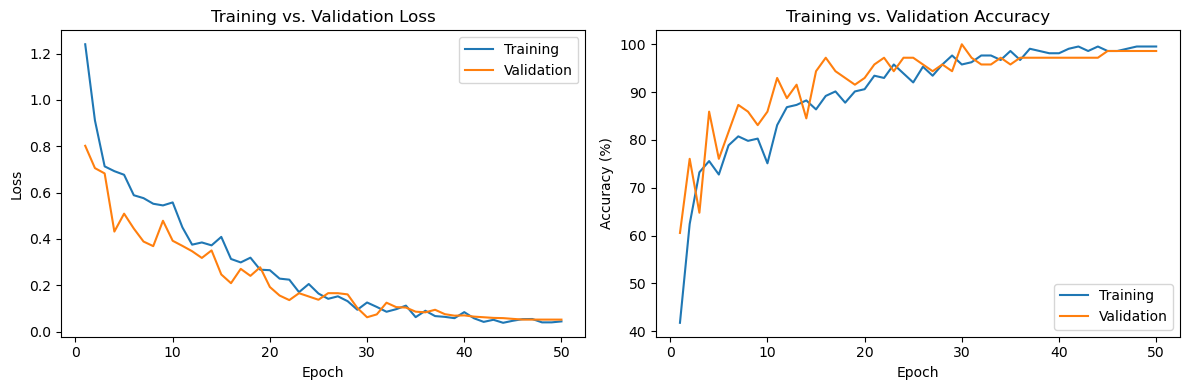

In [13]:
# Plot training curves
epochs = range(1, n_epochs + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs, trn_losses, label='Training')
ax1.plot(epochs, val_losses, label='Validation')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.legend()
ax1.set_title('Training vs. Validation Loss')

ax2.plot(epochs, trn_accs, label='Training')
ax2.plot(epochs, val_accs, label='Validation')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)'); ax2.legend()
ax2.set_title('Training vs. Validation Accuracy')

plt.tight_layout()
plt.show()

In [14]:
# Test evaluation
model.load_state_dict(torch.load('vit_classifier.pth', weights_only=True))
test_loss, test_acc, test_kappa, test_preds, test_labels = validate(
    model, testload, criterion, device
)

print(f"Test Accuracy: {test_acc:.2f}%")
print(f"Test Kappa:    {test_kappa:.4f}")
print()

# Confusion matrix
cm = confusion_matrix(test_labels, test_preds)
print("Confusion Matrix:")
print(cm)
print()

# Per-class accuracy
print("Per-class Accuracy:")
for i in range(nclasses):
    mask = test_labels == i
    if mask.sum() > 0:
        class_acc = (test_preds[mask] == i).sum() / mask.sum() * 100
        print(f"  Class {i+1}: {class_acc:.1f}% ({mask.sum()} samples)")

Test Accuracy: 95.77%
Test Kappa:    0.9474

Confusion Matrix:
[[17  0  0  0  0  1]
 [ 0 15  0  0  0  0]
 [ 0  0  5  0  0  1]
 [ 0  0  0  6  0  0]
 [ 0  1  0  0  9  0]
 [ 0  0  0  0  0 16]]

Per-class Accuracy:
  Class 1: 94.4% (18 samples)
  Class 2: 100.0% (15 samples)
  Class 3: 83.3% (6 samples)
  Class 4: 100.0% (6 samples)
  Class 5: 90.0% (10 samples)
  Class 6: 100.0% (16 samples)


## Exercises

- Compare the ViT results with the CNN results from the previous lecture on the same Corel dataset. Which performs better with limited data and why?
- Try using a pretrained ViT from HuggingFace (`google/vit-base-patch16-224`) and fine-tune it. How does transfer learning compare to training from scratch?
- Experiment with different patch sizes (8, 16, 32). How does patch size affect accuracy and speed?
- Visualize the attention maps from the last encoder block to see what the model focuses on.